## This notebook makes a plot showing different windows. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
import plot_scripts as plts
import os
plt.style.use("mplstyle")

/tmp/ipykernel_252504/1895097715.py:58: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.3)
/tmp/ipykernel_252504/1895097715.py:97: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Plot saved to plots/fig_window_and_transfer_clean.pdf


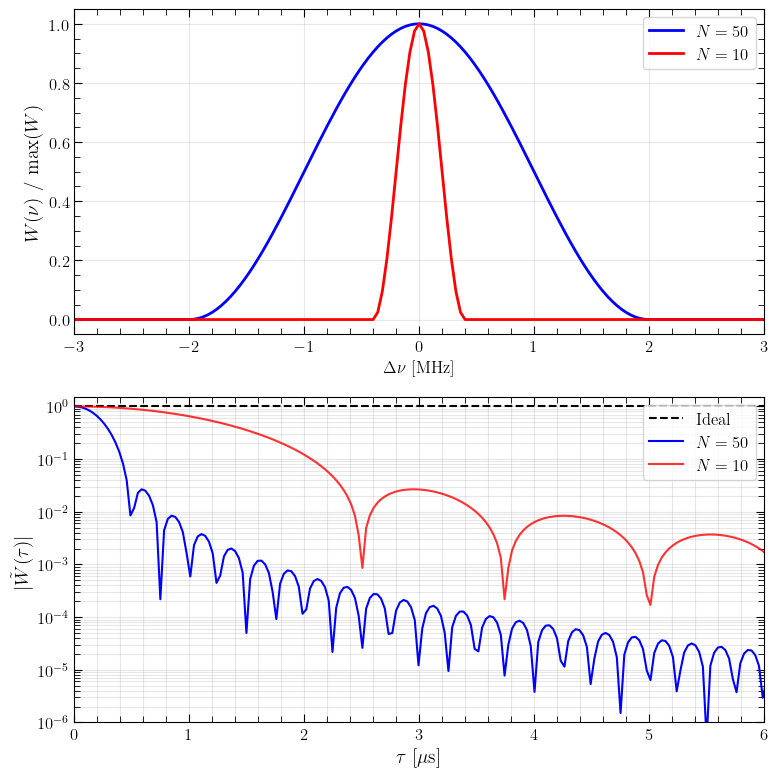

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, fftfreq
import os

# === 1. Parameters ===
N_chan = 768
dnu = 0.04  # MHz

# Frequency Axis (Centered for plotting)
freqs_centered = (np.arange(N_chan) - N_chan//2) * dnu

# Delay Axis
tau = fftshift(fftfreq(N_chan, dnu))
mask = tau >= 0
tau_plot = tau[mask]

# Window Half-Widths (N)
N_wide = 50   # Wide in Frequency (Stiff)
N_narr = 10   # Narrow in Frequency (Flexible)

# Output path
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)
save_fname = os.path.join(output_dir, "fig_window_and_transfer_clean.pdf")

# === 2. Calculation ===
def get_window_and_transfer(N_half):
    # 1. Create Window in Frequency
    win = np.zeros(N_chan)
    hann = np.hanning(2 * N_half + 1)
    center = N_chan // 2
    start = center - N_half
    end = start + len(hann)
    
    # Handle boundary safety
    if end > N_chan: end = N_chan
    win[start:end] = hann[:end-start]
    
    # Normalize (sum=1 is physically correct for convolution conservation)
    win_norm = win / win.sum()
    
    # 2. Compute Transfer Function (Delay)
    # The FFT of a real, symmetric window is real and symmetric.
    # We take abs() just to be safe and for log-plotting.
    W_tau = np.abs(fftshift(fft(win_norm)))
    
    return win, W_tau[mask]

# Generate Data
win_wide, W_wide = get_window_and_transfer(N_wide)
win_narr, W_narr = get_window_and_transfer(N_narr)

# === 3. PLOTTING ===
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm'})

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
plt.subplots_adjust(hspace=0.3)

# --- PANEL A: FREQUENCY DOMAIN (The Window Itself) ---
ax0 = axes[0]

# Normalize peak to 1 for visual comparison of width
ax0.plot(freqs_centered, win_wide / win_wide.max(), 'b-', lw=2, 
         label=r'$N=' + str(N_wide) + '$')
ax0.plot(freqs_centered, win_narr / win_narr.max(), 'r-', lw=2, 
         label=r'$N=' + str(N_narr) + '$')

ax0.set_ylabel(r'$W(\nu) \ / \ \mathrm{max}(W)$', fontsize=14)
ax0.set_xlabel(r'$\Delta\nu\ [\mathrm{MHz}]$', fontsize=12)
ax0.set_xlim(-3, 3) 
ax0.legend(loc='upper right', frameon=True, fontsize=12)
ax0.grid(True, alpha=0.3)
ax0.tick_params(axis='both', which='major', labelsize=12)

# --- PANEL B: DELAY DOMAIN (The Transfer Function) ---
ax1 = axes[1]
ax1.axhline(1.0, color='k', linestyle='--', lw=1.5, label=r'$\mathrm{Ideal}$')

ax1.semilogy(tau_plot, W_wide, 'b-', lw=1.5, 
             label=r'$N=' + str(N_wide) + '$')

ax1.semilogy(tau_plot, W_narr, 'r-', lw=1.5, alpha=0.8, 
             label=r'$N=' + str(N_narr) + '$')

ax1.set_ylabel(r'$|\tilde{W}(\tau)|$', fontsize=14)
ax1.set_xlabel(r'$\tau\ [\mu\mathrm{s}]$', fontsize=14)

# ZOOM OUT to see tails
ax1.set_xlim(0, 6.0) 
ax1.set_ylim(1e-6, 1.5) # Tightened slightly from 3.0 to 1.5

ax1.legend(loc='upper right', fontsize=12)
ax1.grid(True, alpha=0.3, which='both')
ax1.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig(save_fname, bbox_inches='tight')
print(f"Plot saved to {save_fname}")
plt.show()

Target FWHM (Hann N=50): 49 bins
Optimizing window widths...
  Hann: Best N = 49 (Diff: 0.00)
  Blackman-Harris: Best N = 71 (Diff: 0.00)
  Nuttall: Best N = 70 (Diff: 0.00)
  Kaiser ($\beta=14$): Best N = 77 (Diff: 0.00)
  DPSS ($NW=3$): Best N = 62 (Diff: 0.00)
Plot saved to plots/fig_window_matched_fwhm.pdf


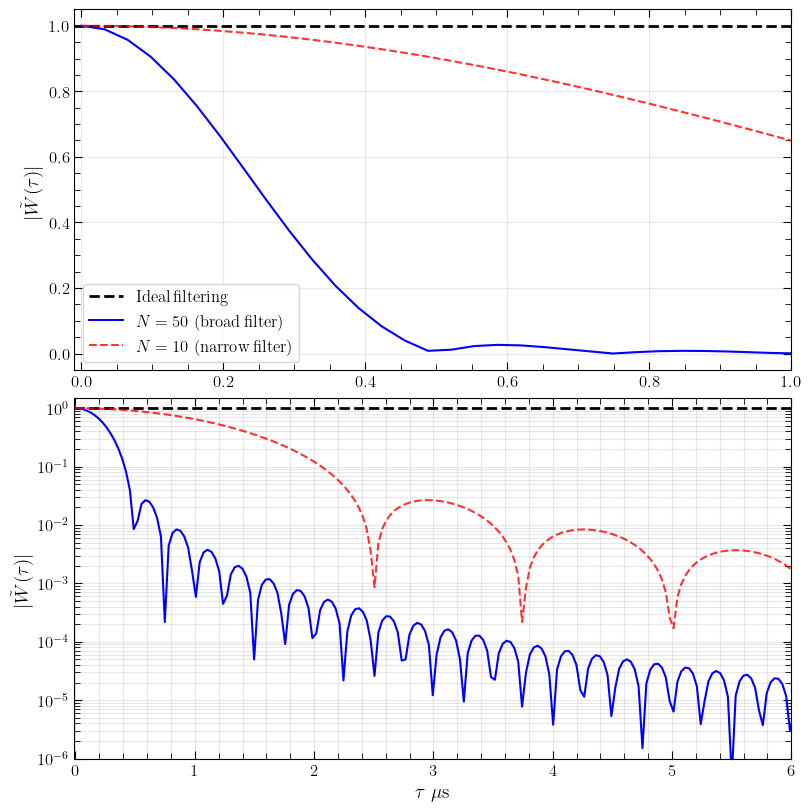

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, fftfreq
import os

# === 1. Parameters ===
N_chan = 768
dnu = 0.04  # MHz

# Frequency Axis (Centered for plotting)
freqs_centered = (np.arange(N_chan) - N_chan//2) * dnu

# Delay Axis
tau = fftshift(fftfreq(N_chan, dnu))
mask = tau >= 0
tau_plot = tau[mask]

# Window Half-Widths (N)
N_wide = 50   # Wide in Frequency (Stiff)
N_narr = 10   # Narrow in Frequency (Flexible)

# Output path
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)
save_fname = os.path.join(output_dir, "transfer_function.pdf")

# === 2. Calculation ===
def get_window_and_transfer(N_half):
    # 1. Create Window in Frequency
    win = np.zeros(N_chan)
    hann = np.hanning(2 * N_half + 1)
    center = N_chan // 2
    start = center - N_half
    end = start + len(hann)
    
    # Handle boundary safety
    if end > N_chan: end = N_chan
    win[start:end] = hann[:end-start]
    
    # Normalize (sum=1 is physically correct for convolution conservation)
    win_norm = win / win.sum()
    
    # 2. Compute Transfer Function (Delay)
    # The FFT of a real, symmetric window is real and symmetric.
    # We take abs() just to be safe and for log-plotting.
    W_tau = np.abs(fftshift(fft(win_norm)))
    
    return win, W_tau[mask]

# Generate Data
win_wide, W_wide = get_window_and_transfer(N_wide)
win_narr, W_narr = get_window_and_transfer(N_narr)

# === 3. PLOTTING ===
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm'})

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
# plt.subplots_adjust(hspace=0.3)

# --- PANEL A: DELAY DOMAIN (Linear Scale) ---
ax0 = axes[0]
ax0.axhline(1.0, color='k', linestyle='--', lw=2, label=r'$\mathrm{Ideal\,filtering}$')

ax0.plot(tau_plot, W_wide, 'b-', lw=1.5, 
         label=r'$N=' + str(N_wide) + '$ ' + r'$\mathrm{(broad\,filter)}$')
ax0.plot(tau_plot, W_narr, 'r--', lw=1.5, alpha=0.8, 
         label=r'$N=' + str(N_narr) + '$ ' + r'$\mathrm{(narrow\,filter)}$')

ax0.set_ylabel(r'$|\tilde{W}(\tau)|$', fontsize=14)
# ax0.set_xlabel(r'$\tau\ [\mu\mathrm{s}]$', fontsize=14)
ax0.set_xlim(-0.01, 1) 
ax0.legend(loc='lower left', frameon=True, fontsize=12)
ax0.grid(True, alpha=0.3)
ax0.tick_params(axis='both', which='major', labelsize=12)

# --- PANEL B: DELAY DOMAIN (Log Scale) ---
ax1 = axes[1]
ax1.axhline(1.0, color='k', linestyle='--', lw=2, label=r'$\mathrm{Ideal\,filtering}$')

ax1.semilogy(tau_plot, W_wide, 'b-', lw=1.5, 
             label=r'$N=' + str(N_wide) + '$')

ax1.semilogy(tau_plot, W_narr, 'r--', lw=1.5, alpha=0.8, 
             label=r'$N=' + str(N_narr) + '$')
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, fftfreq
from scipy.signal import get_window
from scipy.interpolate import interp1d
import os

# === 1. Parameters ===
N_chan = 768
dnu = 0.04  # MHz
freqs_centered = (np.arange(N_chan) - N_chan//2) * dnu

# Delay Axis
tau = fftshift(fftfreq(N_chan, dnu))
mask = tau >= 0
tau_plot = tau[mask]

# Reference: Hann Window with N=50
N_ref_half = 50 

# Output path
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)
save_fname = os.path.join(output_dir, "fig_window_matched_fwhm.pdf")

# === 2. Helper Functions ===

def get_padded_window(w_name, N_half, N_total):
    """Generates a window of length 2*N_half+1, padded to N_total."""
    N_len = 2 * N_half + 1
    
    # get_window handles strings ('hann') or tuples (('kaiser', 14), ('dpss', 3))
    win_kernel = get_window(w_name, N_len)
        
    win_padded = np.zeros(N_total)
    center = N_total // 2
    start = center - N_half
    end = start + len(win_kernel)
    if end > N_total: end = N_total
    win_padded[start:end] = win_kernel[:end-start]
    
    # Normalize (Sum = 1)
    return win_padded / win_padded.sum()

def measure_fwhm(win_padded):
    """Measures FWHM of the window in frequency bins."""
    peak_idx = np.argmax(win_padded)
    peak_val = win_padded[peak_idx]
    half_val = peak_val / 2.0
    
    # Find indices where window > half_val
    indices = np.where(win_padded >= half_val)[0]
    return indices[-1] - indices[0] 

# === 3. Match FWHM ===

# 1. Calculate Target FWHM (Hann, N=50)
win_ref = get_padded_window('hann', N_ref_half, N_chan)
target_fwhm_bins = measure_fwhm(win_ref)

print(f"Target FWHM (Hann N={N_ref_half}): {target_fwhm_bins} bins")

# 2. Find matching N for other windows
# Format: (Label, Scipy_Args)
windows_to_test = [
    ('Hann', 'hann'),
    ('Blackman-Harris', 'blackmanharris'),
    ('Nuttall', 'nuttall'),
    ('Kaiser ($\\beta=14$)', ('kaiser', 14)),
    ('DPSS ($NW=3$)', ('dpss', 3)) 
]

results = {}

print("Optimizing window widths...")
for label, w_name in windows_to_test:
    # Brute force search for N that matches FWHM
    best_N = N_ref_half
    best_diff = 1e9
    
    # Search range: N=10 to N=150
    for N_test in range(10, 150):
        w_test = get_padded_window(w_name, N_test, N_chan)
        fwhm_test = measure_fwhm(w_test)
        diff = abs(fwhm_test - target_fwhm_bins)
        
        if diff < best_diff:
            best_diff = diff
            best_N = N_test
    
    print(f"  {label}: Best N = {best_N} (Diff: {best_diff:.2f})")
    
    # Generate final data
    win_final = get_padded_window(w_name, best_N, N_chan)
    W_tau = np.abs(fftshift(fft(win_final)))
    
    results[label] = {
        'N': best_N,
        'win': win_final,
        'W_tau': W_tau[mask]
    }


ax1.set_ylabel(r'$|\tilde{W}(\tau)|$', fontsize=14)
ax1.set_xlabel(r'$\tau\ \mu\mathrm{s}$', fontsize=14)

# ZOOM OUT to see tails
ax1.set_xlim(-0.01, 6.0) 
ax1.set_ylim(1e-6, 1.5) # Tightened slightly from 3.0 to 1.5

# ax1.legend(loc='lower left', fontsize=12)
ax1.grid(True, alpha=0.3, which='both')
ax1.tick_params(axis='both', which='major', labelsize=12)

# plt.tight_layout()
plt.savefig(save_fname, bbox_inches='tight')
print(f"Plot saved to {save_fname}")
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, fftfreq
from scipy.signal import get_window
from scipy.interpolate import interp1d
import os

# === 1. Parameters ===
N_chan = 768
dnu = 0.04  # MHz
freqs_centered = (np.arange(N_chan) - N_chan//2) * dnu

# Delay Axis
tau = fftshift(fftfreq(N_chan, dnu))
mask = tau >= 0
tau_plot = tau[mask]

# Reference: Hann Window with N=50
N_ref_half = 50 

# Output path
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)
save_fname = os.path.join(output_dir, "fig_window_matched_fwhm.pdf")

# === 2. Helper Functions ===

def get_padded_window(w_name, N_half, N_total):
    """Generates a window of length 2*N_half+1, padded to N_total."""
    N_len = 2 * N_half + 1
    
    # get_window handles strings ('hann') or tuples (('kaiser', 14), ('dpss', 3))
    win_kernel = get_window(w_name, N_len)
        
    win_padded = np.zeros(N_total)
    center = N_total // 2
    start = center - N_half
    end = start + len(win_kernel)
    if end > N_total: end = N_total
    win_padded[start:end] = win_kernel[:end-start]
    
    # Normalize (Sum = 1)
    return win_padded / win_padded.sum()

def measure_fwhm(win_padded):
    """Measures FWHM of the window in frequency bins."""
    peak_idx = np.argmax(win_padded)
    peak_val = win_padded[peak_idx]
    half_val = peak_val / 2.0
    
    # Find indices where window > half_val
    indices = np.where(win_padded >= half_val)[0]
    return indices[-1] - indices[0] 

# === 3. Match FWHM ===

# 1. Calculate Target FWHM (Hann, N=50)
win_ref = get_padded_window('hann', N_ref_half, N_chan)
target_fwhm_bins = measure_fwhm(win_ref)

print(f"Target FWHM (Hann N={N_ref_half}): {target_fwhm_bins} bins")

# 2. Find matching N for other windows
# Format: (Label, Scipy_Args)
windows_to_test = [
    ('Hann', 'hann'),
    ('Blackman-Harris', 'blackmanharris'),
    ('Nuttall', 'nuttall'),
    ('Kaiser ($\\beta=14$)', ('kaiser', 6)),
    # ('DPSS ($NW=3$)', ('dpss', 2)) 
]

results = {}

print("Optimizing window widths...")
for label, w_name in windows_to_test:
    # Brute force search for N that matches FWHM
    best_N = N_ref_half
    best_diff = 1e9
    
    # Search range: N=10 to N=150
    for N_test in range(10, 150):
        w_test = get_padded_window(w_name, N_test, N_chan)
        fwhm_test = measure_fwhm(w_test)
        diff = abs(fwhm_test - target_fwhm_bins)
        
        if diff < best_diff:
            best_diff = diff
            best_N = N_test
    
    print(f"  {label}: Best N = {best_N} (Diff: {best_diff:.2f})")
    
    # Generate final data
    win_final = get_padded_window(w_name, best_N, N_chan)
    W_tau = np.abs(fftshift(fft(win_final)))
    
    results[label] = {
        'N': best_N,
        'win': win_final,
        'W_tau': W_tau[mask]
    }



Target FWHM (Hann N=50): 49 bins
Optimizing window widths...
  Hann: Best N = 49 (Diff: 0.00)
  Blackman-Harris: Best N = 71 (Diff: 0.00)
  Nuttall: Best N = 70 (Diff: 0.00)
  Kaiser ($\beta=14$): Best N = 50 (Diff: 0.00)


In [14]:
results['Hann']['N']  = 50

/tmp/ipykernel_252504/1990584499.py:5: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.3)
/tmp/ipykernel_252504/1990584499.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Plot saved to plots/fig_window_matched_fwhm.pdf


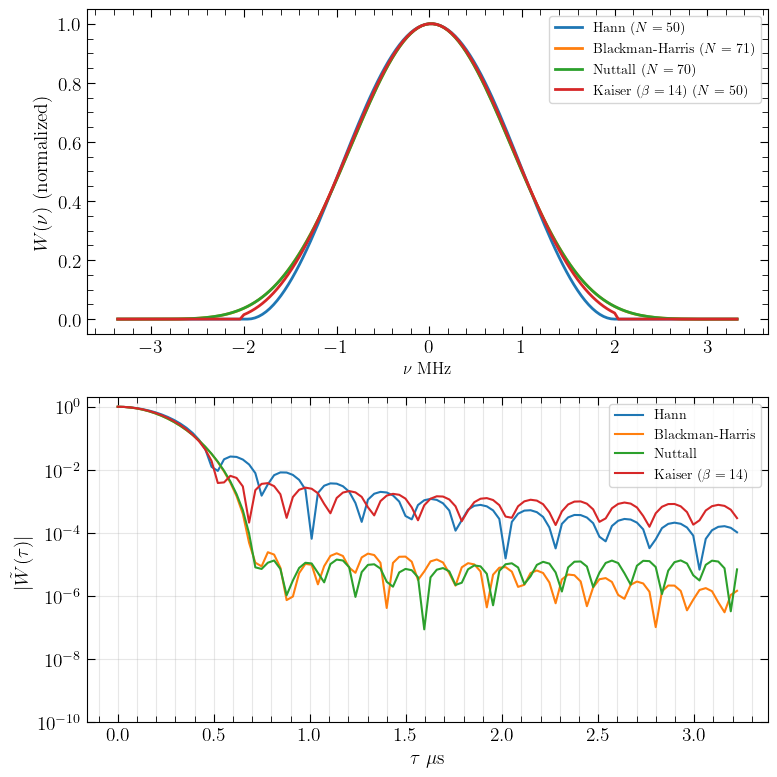

In [15]:
# === 4. PLOTTING ===
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm'})

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
plt.subplots_adjust(hspace=0.3)

# --- PANEL A: FREQUENCY DOMAIN (Window Shape) ---
ax0 = axes[0]

for label, _ in windows_to_test:
    data = results[label]
    win = data['win']
    N_val = data['N']
    ax0.plot(freqs_centered[300:-300], win[300:-300] / win.max(), lw=2, 
             label=f"{label} ($N={N_val}$)")

ax0.set_ylabel(r'$W(\nu) \ \mathrm{(normalized)} $', fontsize=14)
ax0.set_xlabel(r'$\nu\ \mathrm{MHz}$', fontsize=12)
# ax0.set_xlim(-4, 4)
ax0.legend(loc='upper right', frameon=True, fontsize=10)
# ax0.grid(True, alpha=0.3)
# ax0.set_title(r'$\mathrm{Window\ Shapes\ (Matched\ FWHM)}$', fontsize=12)

# --- PANEL B: DELAY DOMAIN (Sidelobes) ---
ax1 = axes[1]
# ax1.axhline(1.0, color='k', linestyle='--', lw=1.5, label=r'$\mathrm{Ideal}$')

for label, _ in windows_to_test:
    data = results[label]
    W_tau = data['W_tau']
    ax1.semilogy(tau_plot[:100], W_tau[:100], lw=1.5, label=label)

ax1.set_ylabel(r'$|\tilde{W}(\tau)|$', fontsize=14)
ax1.set_xlabel(r'$\tau\ \mu\mathrm{s}$', fontsize=14)
# ax1.set_title(r'$\mathrm{Transfer\ Function}$', fontsize=12)

# Focus on tails
# ax1.set_xlim(-0.1, 6.1)
ax1.set_ylim(1e-10, 2.0)

ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(save_fname, bbox_inches='tight')
print(f"Plot saved to {save_fname}")
plt.show()